<a href="https://colab.research.google.com/github/MeLBiN122/AI-ML/blob/main/intern_day3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,MinMaxScaler,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import skew
import numpy as np
from sklearn.preprocessing import PowerTransformer

In [2]:
df = pd.read_csv("/content/boston.csv")

In [3]:
standard_scaler = StandardScaler()

df[['crim','zn','indus','chas','nox','rm','age','dis','rad','tax','ptratio','b','lstat','medv']] = standard_scaler.fit_transform(
    df[['crim','zn','indus','chas','nox','rm','age','dis','rad','tax','ptratio','b','lstat','medv']])

In [4]:
minmax_scaler = MinMaxScaler()

df[['crim','zn','indus','chas','nox','rm','age','dis','rad','tax','ptratio','b','lstat','medv']] = minmax_scaler.fit_transform(df[['crim','zn','indus','chas','nox','rm','age','dis','rad','tax','ptratio','b','lstat','medv']])

Missing Values:
 crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

Summary Statistics:
              crim          zn         indus        chas           nox  \
count  506.000000  506.000000  5.060000e+02  506.000000  5.060000e+02   
mean     0.036362    0.090296  4.212704e-17    0.047945  1.685082e-16   
std      0.077805    0.175973  1.000990e+00    0.176055  1.000990e+00   
min      0.000000    0.000000 -1.854271e+00    0.000000 -1.937274e+00   
25%      0.000851    0.000000 -8.511791e-01    0.000000 -9.615450e-01   
50%      0.002808    0.000000 -8.328309e-02    0.000000  3.871634e-02   
75%      0.040430    0.117783  1.030141e+00    0.000000  7.489990e-01   
max      0.693147    0.693147  1.975831e+00    0.693147  2.029045e+00   

                 rm           age         dis         rad           tax  \
count  5.060000e+02  5.060000e+02

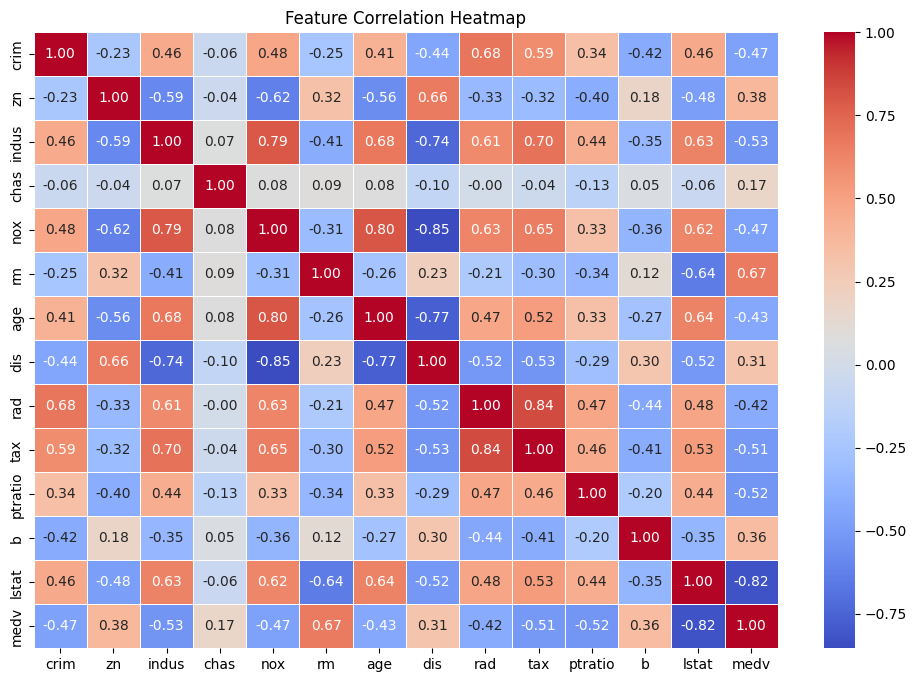

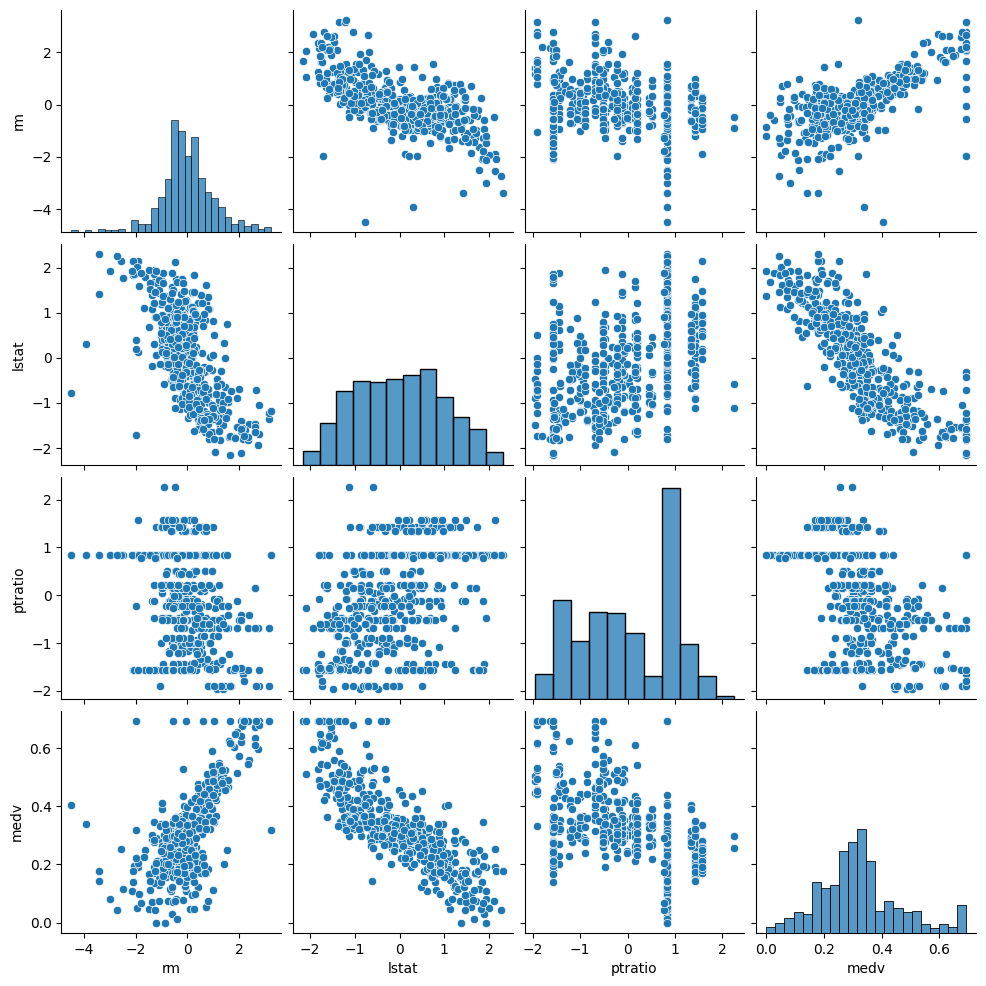

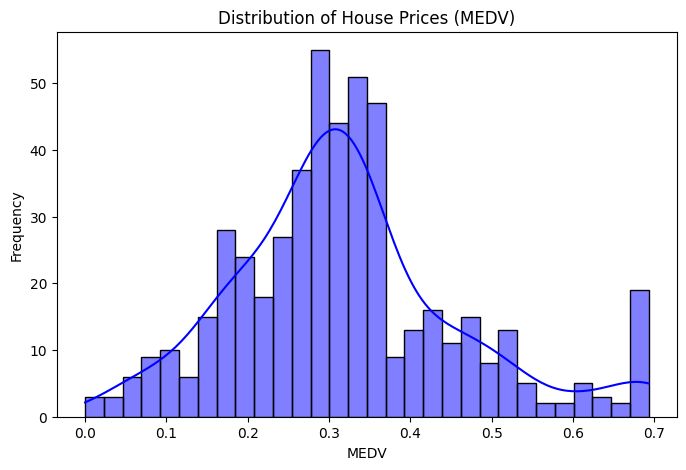

In [17]:

# Check for missing values
print("Missing Values:\n", df.isnull().sum())

# Summary statistics
print("\nSummary Statistics:\n", df.describe())

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
# the annotation would show the correlation values for each pair of variables in your DataFrame.
#annot=True, you're asking the heatmap to display the actual numeric value inside each colored cell.
plt.title("Feature Correlation Heatmap")

plt.show()

# Pairplot for key variables
sns.pairplot(df[['rm', 'lstat', 'ptratio', 'medv']])
plt.show()

# Distribution of target variable (MEDV)
plt.figure(figsize=(8, 5))
sns.histplot(df['medv'], bins=30, kde=True, color='blue')
plt.title("Distribution of House Prices (MEDV)")
plt.xlabel("MEDV")
plt.ylabel("Frequency")
plt.show()

In [5]:
X = df.drop(columns=["medv"])
y = df["medv"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)

rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.6688
RMSE: 0.1095


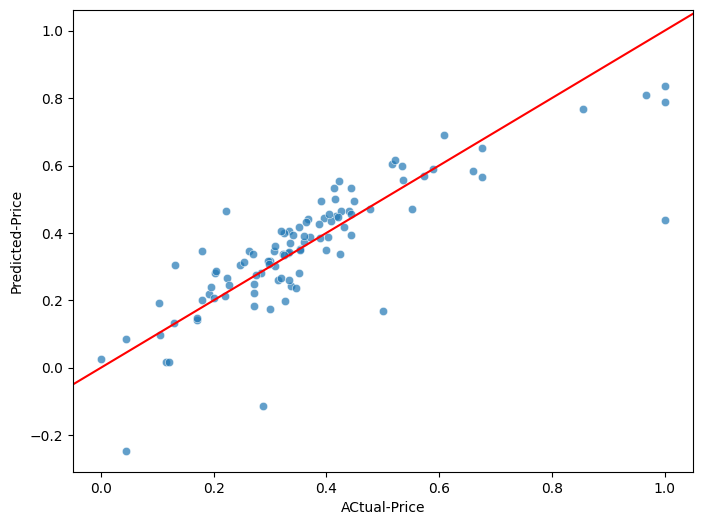

In [6]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test,y=y_pred,alpha=0.7)
plt.xlabel('ACtual-Price')
plt.ylabel('Predicted-Price')
plt.axline([0,0],[1,1],color='red',linestyle='solid')
plt.show()

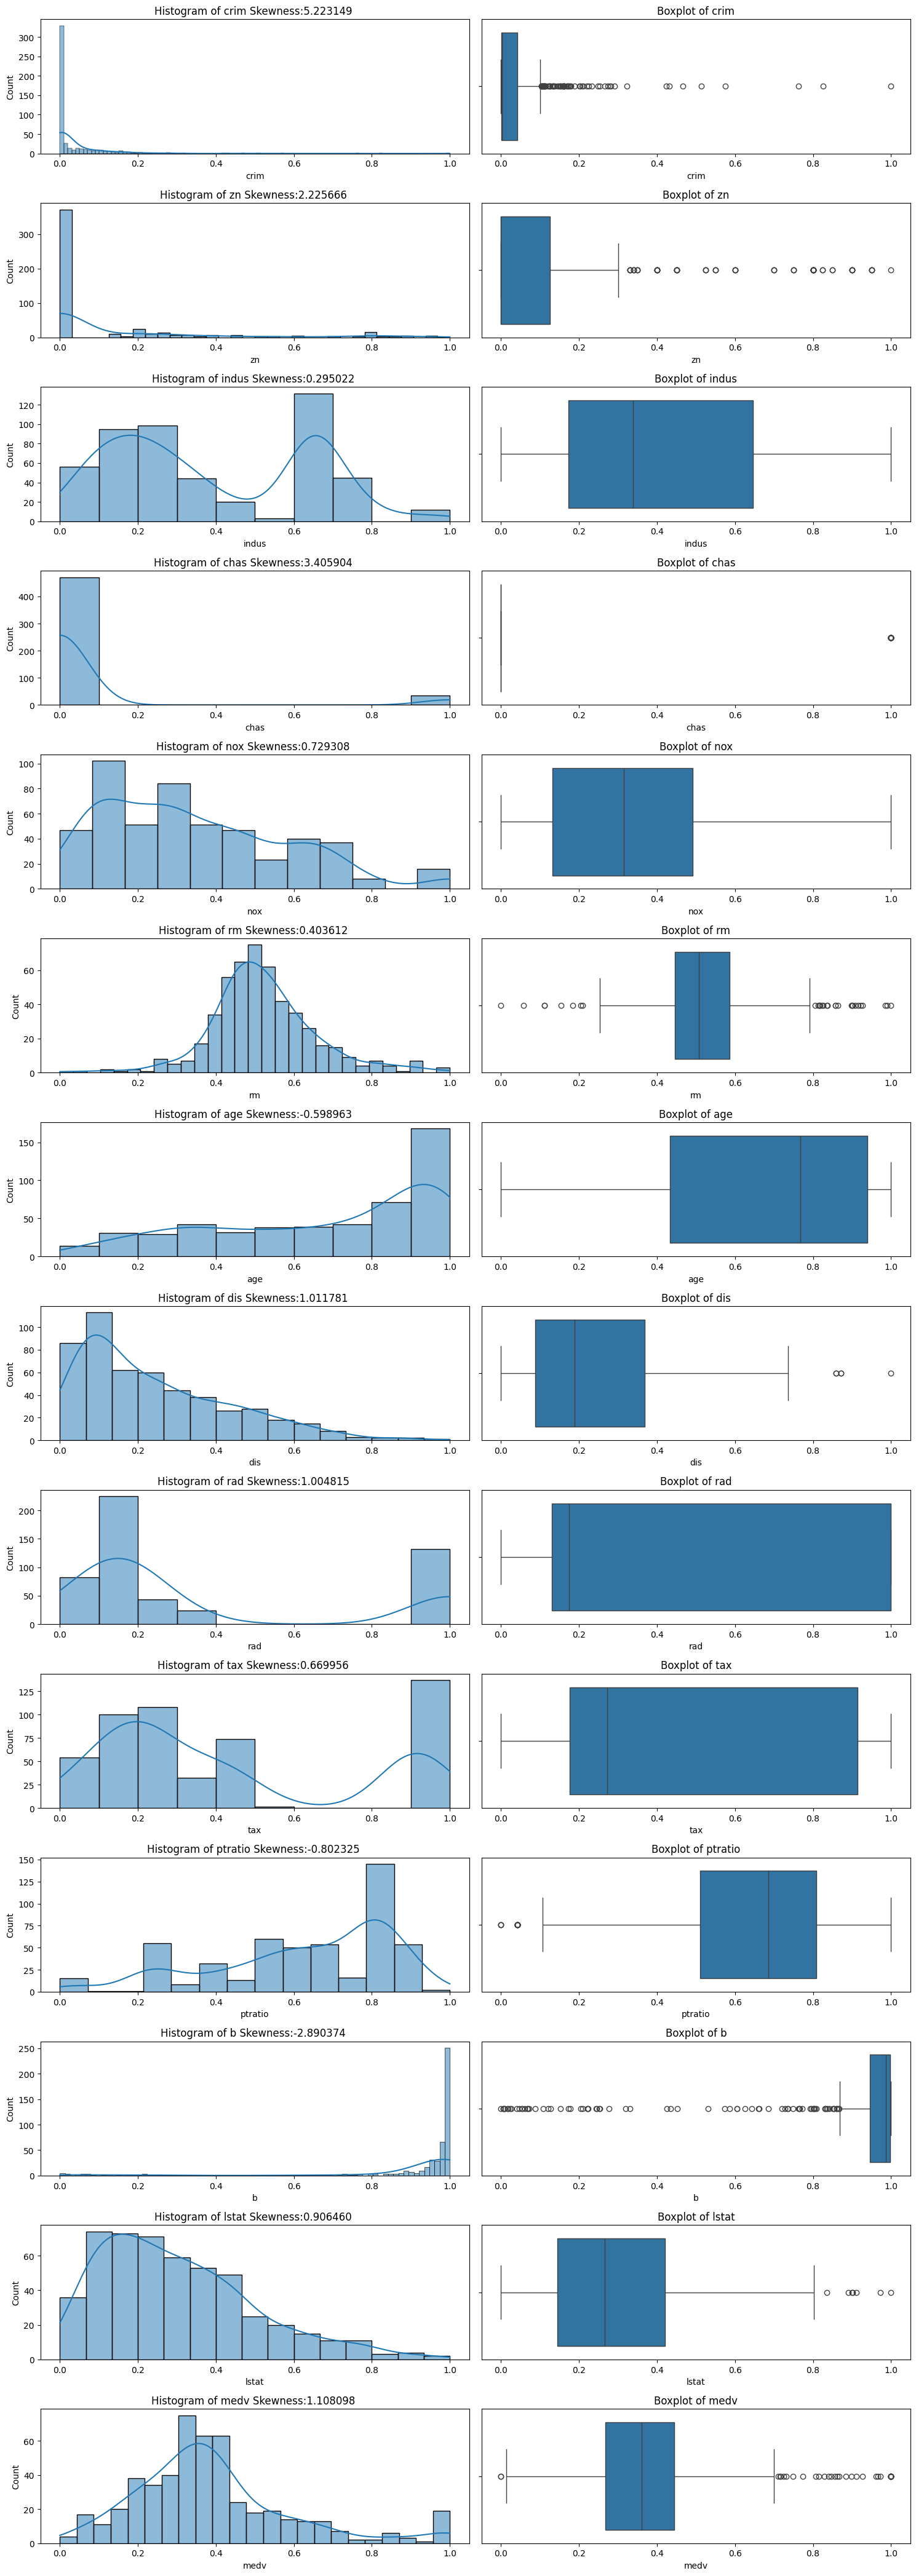

In [7]:
skewness = df.skew()
num_cols=len(df.columns)
plt.figure(figsize=(15,num_cols*3))

for i,col in enumerate(df.columns):
    plt.subplot(num_cols,2,2*i+1)
    sns.histplot(df[col],kde=True)
    plt.title(f'Histogram of {col} Skewness:{skewness[col]:2f} ')

    plt.subplot(num_cols,2,2*i+2)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [13]:
skewness = df.skew()
print(skewness)

crim       4.128753
zn         1.969749
indus      0.040955
chas       3.405904
nox        0.069736
rm         0.016335
age       -0.277712
dis        0.734378
rad        0.938857
tax        0.155182
ptratio   -0.234854
b         -3.084347
lstat      0.072303
medv       0.639214
dtype: float64


In [8]:
skewed_cols = df.skew().abs()
highly_skewed = skewed_cols[skewed_cols > 1].index
neg_skewed = skewed_cols[skewed_cols < 1].index
print(highly_skewed)
print(neg_skewed)

Index(['crim', 'zn', 'chas', 'dis', 'rad', 'b', 'medv'], dtype='object')
Index(['indus', 'nox', 'rm', 'age', 'tax', 'ptratio', 'lstat'], dtype='object')


In [9]:
df[highly_skewed] = df[highly_skewed].apply(lambda x : np.log1p(x))

In [10]:
pt = PowerTransformer(method='yeo-johnson')
df[neg_skewed] = pt.fit_transform(df[neg_skewed])

In [11]:
df.skew()

,0
crim,4.128753
zn,1.969749
indus,0.040955
chas,3.405904
nox,0.069736
rm,0.016335
age,-0.277712
dis,0.734378
rad,0.938857
tax,0.155182


In [14]:
X = df.drop(columns=["medv"])  # All columns except target
y = df["medv"]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.7539
RMSE: 0.0650


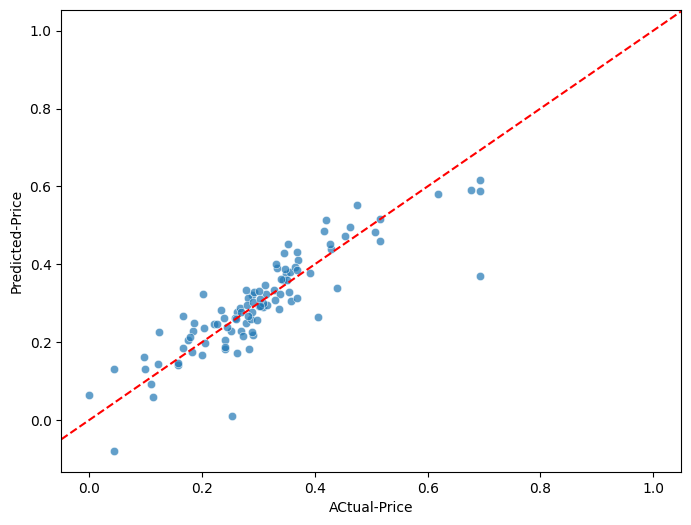

In [15]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test,y=y_pred,alpha=0.7)
plt.xlabel('ACtual-Price')
plt.ylabel('Predicted-Price')
plt.axline([0,0],[1,1],color='red',linestyle='--')
plt.show()